In [19]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import networkx as nx
from torch_geometric.utils import to_networkx
from torch_geometric.datasets import KarateClub

#### Karate Club Dataset Info:
- This dataset holds exactly one graph, 
- Each node in this dataset is assigned a 34-dimensional feature vector (which uniquely describes the members of the karate club). 
- The graph holds exactly 4 classes, which represent the community each node belongs to.

###### ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Zachary’s karate club network from the **An Information Flow Model for Conflict and Fission in Small Groups** paper, containing 34 nodes, connected by 156 (undirected and unweighted) edges. Every node is labeled by one of four classes obtained via modularity-based clustering, following the “Semi-supervised Classification with Graph Convolutional Networks” paper. Training is based on a single labeled example per class, i.e. a total number of 4 labeled nodes.

```
#nodes  #edges  #features   #classes
34      156     34          4
```


In [5]:
dataset = KarateClub()

In [14]:
print("Number of graphs: ", len(dataset))
print("Number of features: ", dataset.num_features)
print("Number of classes: ",dataset.num_classes)
print("Number of node features: ",dataset.num_node_features) ## each node has how many feature?
print("Number of edge features: ",dataset.num_edge_features)

Number of graphs:  1
Number of features:  34
Number of classes:  4
Number of node features:  34
Number of edge features:  0


### Dataset <-> data
Each graph in PyTorch Geometric is represented by a single Data object, which holds all the information to describe its graph representation.

https://pytorch-geometric.readthedocs.io/en/latest/notes/introduction.html
- **data.x**: Node feature matrix with shape ```[num_nodes, num_node_features]```
- **data.edge_index**: Graph connectivity in COO format with shape ```[2, num_edges]``` and type torch.long
- **data.edge_attr**: Edge feature matrix with shape `[num_edges, num_edge_features]`
- **data.y**: Target to train against (may have arbitrary shape), e.g., node-level targets of shape `[num_nodes, *]` or graph-level targets of shape ```[1, *]```
- **data.pos**: Node position matrix with shape `[num_nodes, num_dimensions]`

In [23]:
data = dataset[0]
print(data)

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])


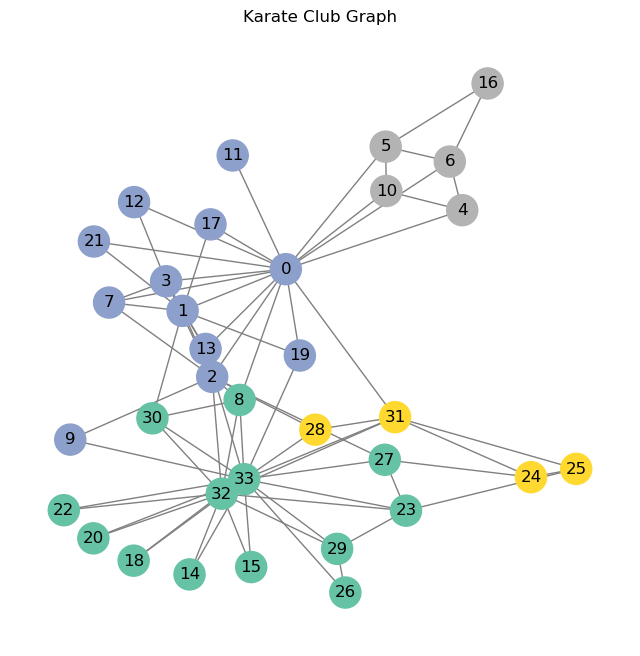

In [31]:
# Convert to networkx
G = to_networkx(data, to_undirected=True)

# Node colors from labels
node_color = data.y.numpy()

# Draw
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos=pos,
    node_color=node_color,
    cmap=plt.cm.Set2,
    with_labels=True,
    node_size=500,
    edge_color="gray"
)

plt.title("Karate Club Graph")
plt.axis("off")
plt.show()

In [25]:
print(data)
print("Node features shape:", data.x.shape)
print("Edge index shape:", data.edge_index.shape)
print("Labels:", data.y)

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
Node features shape: torch.Size([34, 34])
Edge index shape: torch.Size([2, 156])
Labels: tensor([1, 1, 1, 1, 3, 3, 3, 1, 0, 1, 3, 1, 1, 1, 0, 0, 3, 1, 0, 1, 0, 1, 0, 0,
        2, 2, 0, 0, 2, 0, 0, 2, 0, 0])


In [42]:
print(data.x.shape) 
print(data.x)           # node features
print("------------------")
print(data.edge_index.shape)
print(data.edge_index)  # graph connectivity

torch.Size([34, 34])
tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])
------------------
torch.Size([2, 156])
tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,
          3,  3,  3,  3,  3,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,
          7,  7,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10, 11, 12, 12, 13, 13, 13,
         13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 20, 20, 21,
         21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26, 27, 27,
         27, 27, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31,
         31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33,
         33, 33, 33, 33, 33, 33, 33, 

In [44]:
print("------------------")
print(data.y.shape)           
print(data.y)           # labels/classes
print("------------------")
print(data.num_nodes)
print(data.num_edges)

------------------
torch.Size([34])
tensor([1, 1, 1, 1, 3, 3, 3, 1, 0, 1, 3, 1, 1, 1, 0, 0, 3, 1, 0, 1, 0, 1, 0, 0,
        2, 2, 0, 0, 2, 0, 0, 2, 0, 0])
------------------
34
156


---
---
---
## Understanding the KarateClub Dataset in PyTorch Geometric

The `KarateClub` dataset is a small graph dataset commonly used for experimenting with Graph Neural Networks (GNNs).

The graph is represented as:

$$
G = (V, E)
$$

where:

- $V$ = set of nodes
- $E$ = set of edges

---

#### Dataset Object

```python
print(data)
```

Output:

```python
Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
```

This means:

| Attribute | Meaning |
|---|---|
| `x=[34,34]` | node feature matrix |
| `edge_index=[2,156]` | graph connectivity |
| `y=[34]` | node labels |
| `train_mask=[34]` | training nodes mask |

---

### 1. Node Feature Matrix: `data.x`

```python
print(data.x.shape)
```

Output:

```python
torch.Size([34, 34])
```

The feature matrix is:

$$
X \in \mathbb{R}^{34 \times 34}
$$

General form:

$$
X \in \mathbb{R}^{N \times F}
$$

where:

- $N$ = number of nodes
- $F$ = number of node features

For this dataset:

- Number of nodes = 34
- Number of features = 34

---

#### Why are there 34 features?

The dataset uses **one-hot identity encoding**.

Example:

```python
tensor([1.,0.,0.,0.,...])
```

means:

- this is node 0

Another:

```python
tensor([0.,1.,0.,0.,...])
```

means:

- this is node 1

Thus every node gets a unique basis vector.

So the feature matrix is essentially:

$$
X = I_{34}
$$

where $I_{34}$ is the $34 \times 34$ identity matrix.

This is commonly used when no real node features exist.

---

### 2. Graph Connectivity: `data.edge_index`

```python
print(data.edge_index.shape)
```

Output:

```python
torch.Size([2, 156])
```

The connectivity tensor has shape:

$$
\text{edge\_index} \in \mathbb{N}^{2 \times E}
$$

where:

- first row = source nodes
- second row = target nodes
- $E$ = number of edges

---

#### Edge Representation

Each column corresponds to one edge.

Example:

```python
tensor([
 [0],
 [1]
])
```

means:

$$
0 \rightarrow 1
$$

Another:

```python
tensor([
 [0],
 [2]
])
```

means:

$$
0 \rightarrow 2
$$

So each edge is represented as:

$$
e_k =
\begin{bmatrix}
\text{source} \\
\text{target}
\end{bmatrix}
$$

---

#### Why are there 156 edges?

The original Karate Club graph has 78 undirected edges.

PyTorch Geometric stores both directions:

$$
0 - 1
$$

becomes:

$$
0 \rightarrow 1
$$

and

$$
1 \rightarrow 0
$$

Therefore:

$$
156 = 2 \times 78
$$

This makes message passing easier for GNNs.

---

### 3. Labels: `data.y`

```python
print(data.y.shape)
```

Output:

```python
torch.Size([34])
```

There is one label per node:

$$
y \in \{0,1,2,3\}^{34}
$$

Example:

```python
tensor([1,1,1,3,...])
```

means:

- node 0 belongs to class 1
- node 1 belongs to class 1
- node 3 belongs to class 3

etc.

---

### 4. Number of Nodes

```python
print(data.num_nodes)
```

Output:

```python
34
```

Mathematically:

$$
|V| = 34
$$

---

### 5. Number of Edges

```python
print(data.num_edges)
```

Output:

```python
156
```

Mathematically:

$$
|E| = 156
$$

---

#### Overall Graph Representation

The graph is internally represented using:

## Feature Matrix

$$
X \in \mathbb{R}^{N \times F}
$$

## Adjacency Information

$$
A \in \mathbb{R}^{N \times N}
$$

represented efficiently through `edge_index`.

## Labels

$$
y \in \{1,\dots,C\}^{N}
$$

where:

- $C$ = number of classes

---

#### How Graph Neural Networks Use This

A Graph Neural Network repeatedly:

1. gathers neighbor information
2. aggregates messages
3. updates node embeddings

Core GCN propagation equation:

$$
H^{(l+1)}
=
\sigma
\left(
\hat{D}^{-1/2}
\hat{A}
\hat{D}^{-1/2}
H^{(l)}
W^{(l)}
\right)
$$

where:

- $\hat{A}$ = adjacency matrix with self-loops
- $\hat{D}$ = degree matrix
- $H^{(l)}$ = node embeddings at layer $l$
- $W^{(l)}$ = learnable weights

Initially:

$$
H^{(0)} = X
$$

The labels $y$ are used for supervised training.

---

#### Intuition

| Object | Meaning |
|---|---|
| `x` | what each node is |
| `edge_index` | who connects to whom |
| `y` | node class/community |
| GNN | neighbor-aware feature transformation |

This tensor representation is the standard low-level representation used in modern graph machine learning.